In [1]:
# ============================================
# PROJECT 1: Cardiovascular Disease Prediction
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC



In [99]:
df = pd.read_excel(
    r'C:\Users\jarry\Downloads\cardio_train (1).xlsx'
)

# Split the single column into proper columns
df = df.iloc[:,0].str.split(';', expand=True)

# Set first row as column names
df.columns = df.iloc[0]
df = df[1:]
df.columns = [
    'id', 'age', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
    'smoke', 'alco', 'active', 'cardio'
]

df = df.apply(pd.to_numeric, errors='coerce')


print(df.dtypes)
print(df.head())
print(df.info())
print(df.shape)

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   
5   8  21914       1     151    67.0    120     80            2     2      0   

   alco  active  cardio  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
5     0       0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [101]:
df.columns = [
    'id', 'age', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
    'smoke', 'alco', 'active', 'cardio'
]


df = df.apply(pd.to_numeric, errors='coerce')


df = df.dropna()


df['age'] = (df['age'] / 365).astype(int)

# Verify ages
print(df['age'].head())
print(df['age'].describe())

1    55
2    51
3    48
4    47
5    60
Name: age, dtype: int32
count    69999.000000
mean        52.840712
std          6.766813
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


In [103]:
print("\nMissing values:")
print(df.isnull().sum())

print("Duplicates:",df.duplicated().sum())
df.drop_duplicates(inplace=True)




Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Duplicates: 0


In [105]:
df['BMI'] = df['weight'] / ((df['height']/100)**2)

df = df[(df['ap_hi']<250) & (df['ap_hi']>50)]
df = df[(df['ap_lo']<200) & (df['ap_lo']>30)]
df = df[(df['height']>100)]
df = df[(df['weight']>30)]

print("Cleaned Shape:",df.shape)

Cleaned Shape: (68736, 14)


In [107]:
print(df.columns)

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI'],
      dtype='object')


In [109]:
print(df.dtypes)

id               int64
age              int32
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
BMI            float64
dtype: object


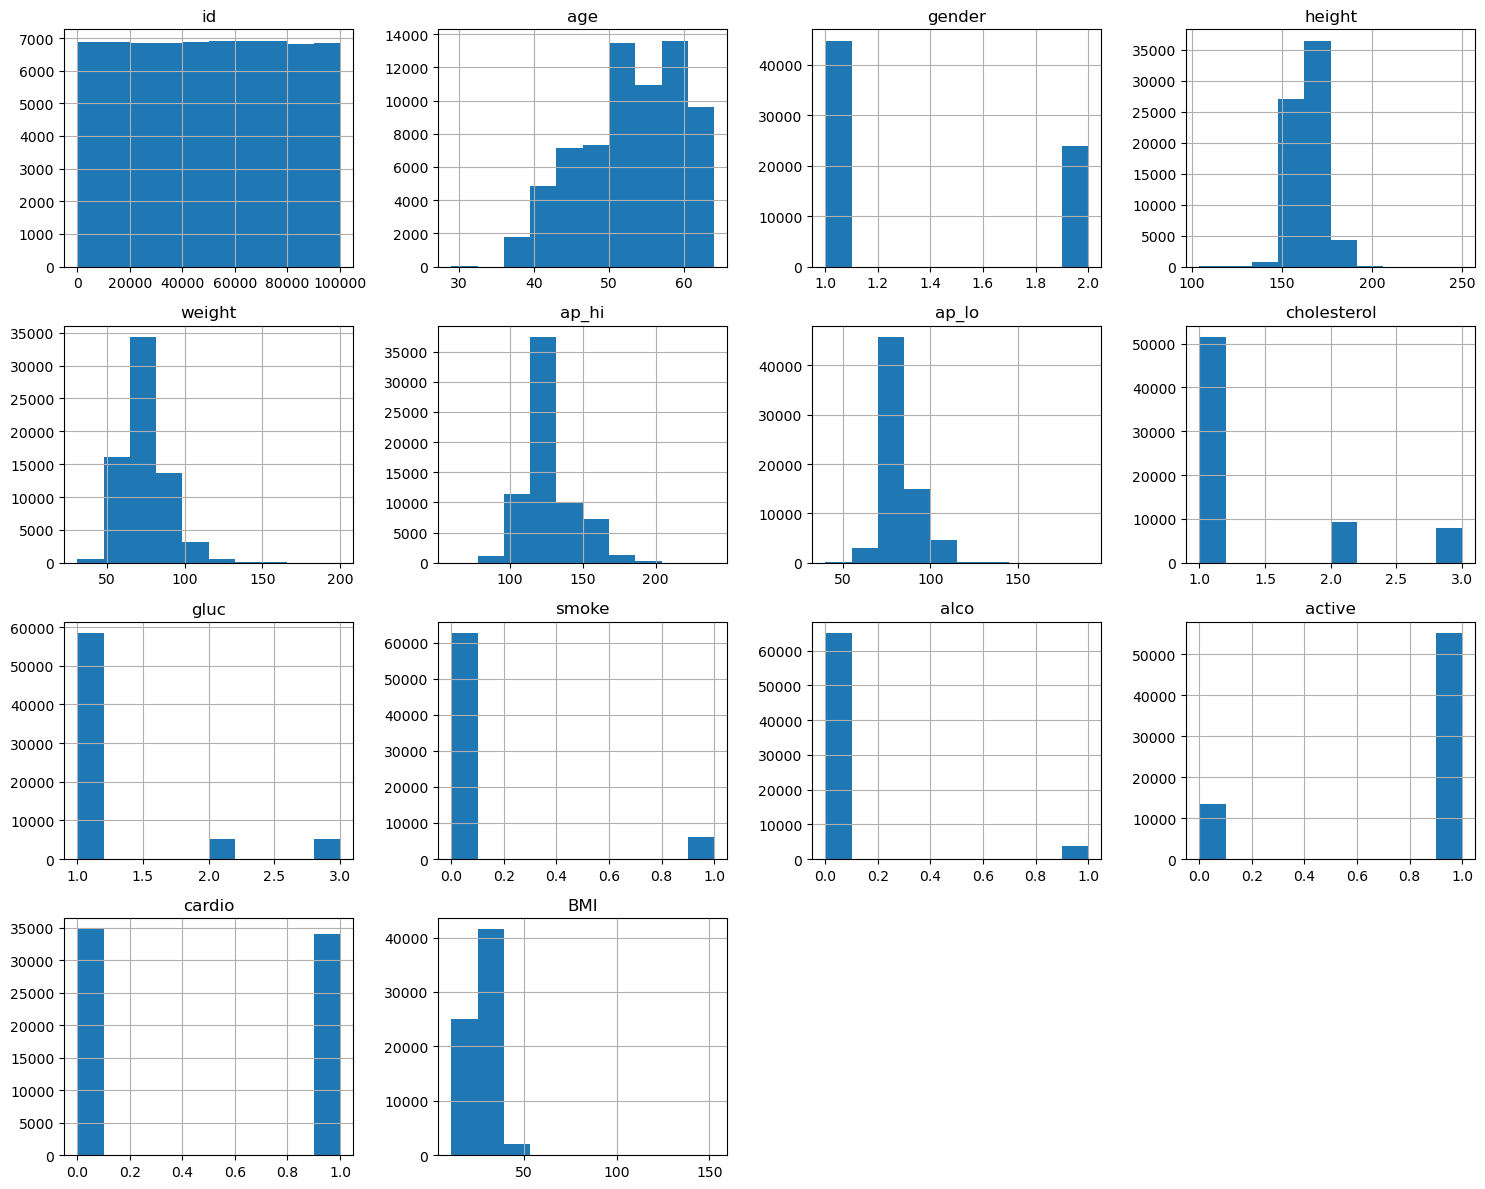

In [111]:
# ---------------------------------
# EXPLORATORY DATA ANALYSIS
# ---------------------------------

# Histograms

df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()


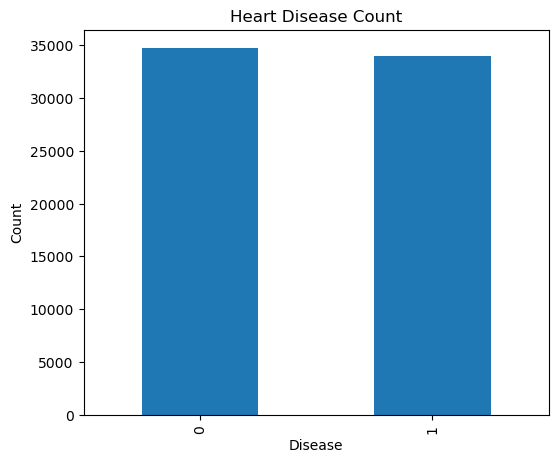

In [113]:
# CARDIO DISEASE COUNT

plt.figure(figsize=(6,5))
df['cardio'].value_counts().plot(kind='bar')
plt.title('Heart Disease Count')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.show()

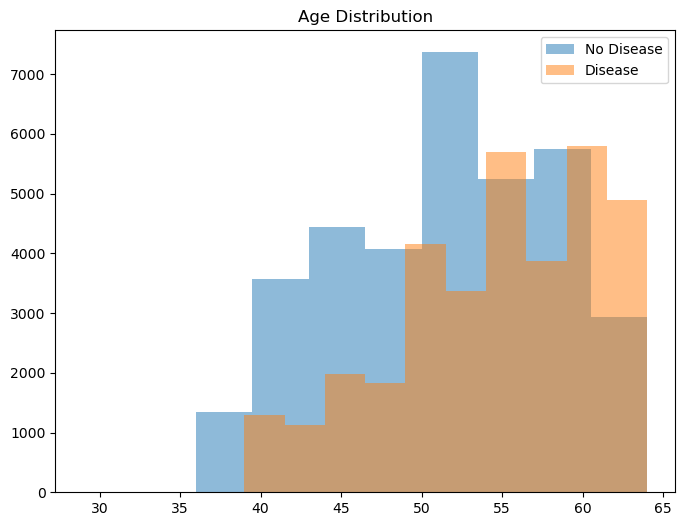

In [115]:
# AGE VS DISEASE

plt.figure(figsize=(8,6))
plt.hist(df[df['cardio']==0]['age'],alpha=.5,label='No Disease')
plt.hist(df[df['cardio']==1]['age'],alpha=.5,label='Disease')
plt.legend()
plt.title('Age Distribution')
plt.show()

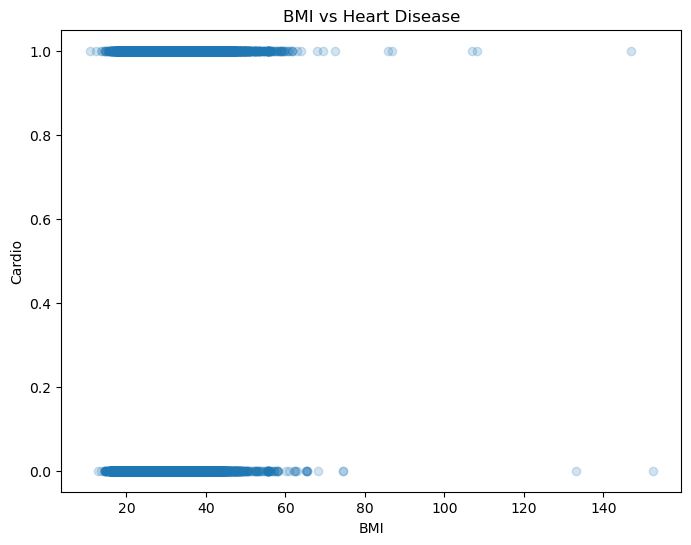

In [123]:
# BMI vs Disease

plt.figure(figsize=(8,6))
plt.scatter(df['BMI'],df['cardio'],alpha=.2)
plt.xlabel("BMI")
plt.ylabel("Cardio")
plt.title("BMI vs Heart Disease")
plt.show()

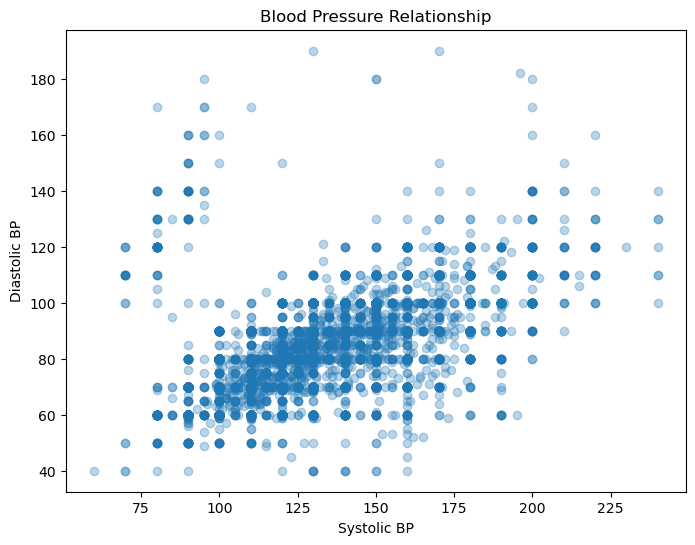

In [119]:
# Blood pressure relationship

plt.figure(figsize=(8,6))
plt.scatter(df['ap_hi'],df['ap_lo'],alpha=.3)
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.title('Blood Pressure Relationship')
plt.show()


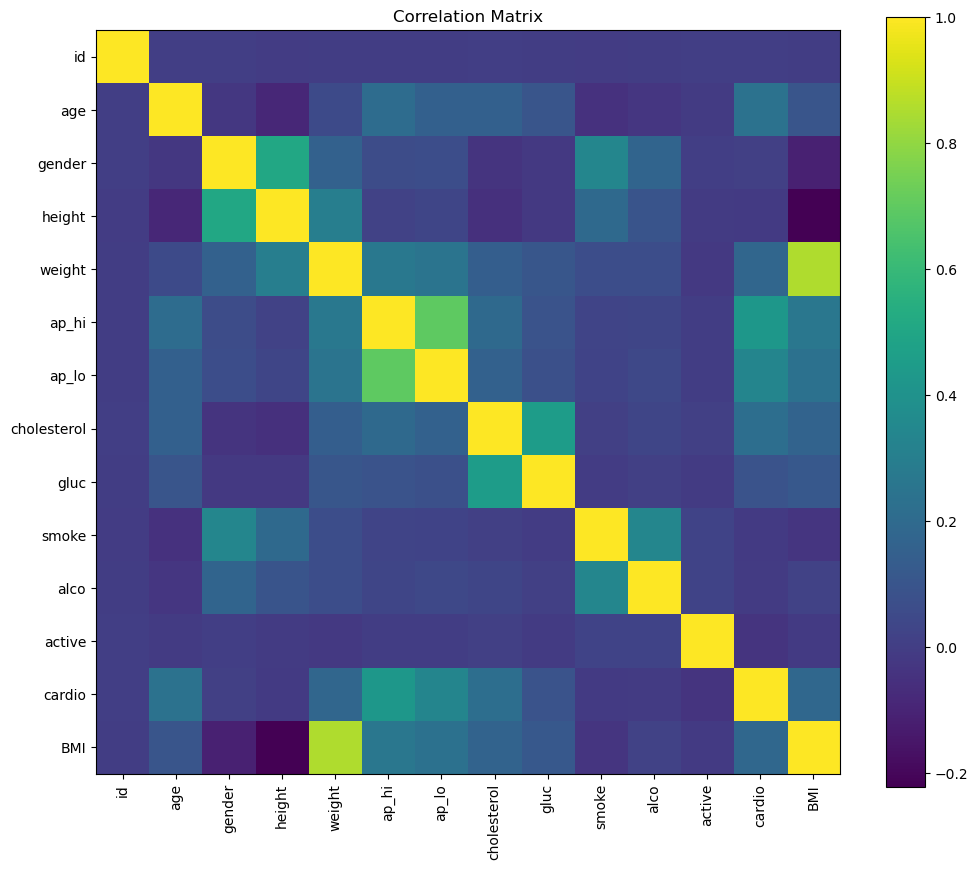

cardio         1.000000
ap_hi          0.425061
ap_lo          0.334989
age            0.239395
cholesterol    0.221562
BMI            0.186560
weight         0.179770
gluc           0.090053
gender         0.007327
id             0.003757
alco          -0.008122
height        -0.012142
smoke         -0.016327
active        -0.037355
Name: cardio, dtype: float64


In [125]:
# CORRELATION MATRIX
# ---------------------------------

corr=df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title('Correlation Matrix')
plt.show()

print(corr['cardio'].sort_values(ascending=False))


In [127]:
# FEATURE SELECTION

X=df.drop(['cardio','id'],axis=1)
y=df['cardio']


In [129]:
# TRAIN TEST SPLIT

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [131]:
# FEATURE SCALING

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [133]:
# TRAIN MODELS

models={
    'Logistic Regression':LogisticRegression(max_iter=1000),

    'KNN':KNeighborsClassifier(n_neighbors=7),

    'Decision Tree':DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest':RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'SVM':SVC()
}

results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,pred)

    results.append([name,accuracy])

    print("\n",name)
    print("Accuracy:",accuracy)
    print(classification_report(y_test,pred))



 Logistic Regression
Accuracy: 0.7249054407913879
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6900
           1       0.75      0.67      0.71      6848

    accuracy                           0.72     13748
   macro avg       0.73      0.72      0.72     13748
weighted avg       0.73      0.72      0.72     13748


 KNN
Accuracy: 0.7021384928716904
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6900
           1       0.71      0.68      0.70      6848

    accuracy                           0.70     13748
   macro avg       0.70      0.70      0.70     13748
weighted avg       0.70      0.70      0.70     13748


 Decision Tree
Accuracy: 0.6370381146348559
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      6900
           1       0.64      0.62      0.63      6848

    accuracy                           0.64     137

                 Model  Accuracy
0  Logistic Regression  0.724905
1                  KNN  0.702138
2        Decision Tree  0.637038
3        Random Forest  0.708903
4                  SVM  0.732616


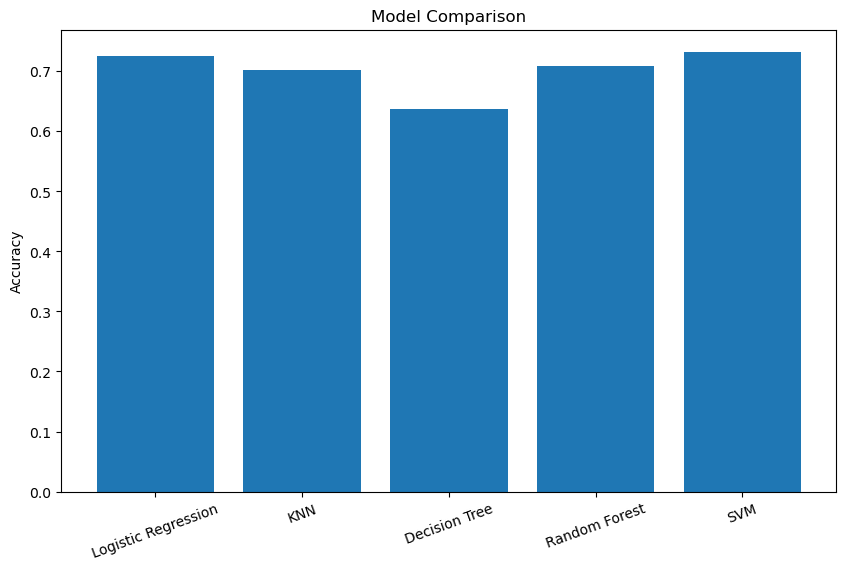

In [137]:
# MODEL COMPARISON

results_df=pd.DataFrame(
    results,
    columns=['Model','Accuracy']
)

print(results_df)


plt.figure(figsize=(10,6))
plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.xticks(rotation=20)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()


In [141]:
best_model = SVC()

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, prediction))

Final Accuracy: 0.7326156531859179


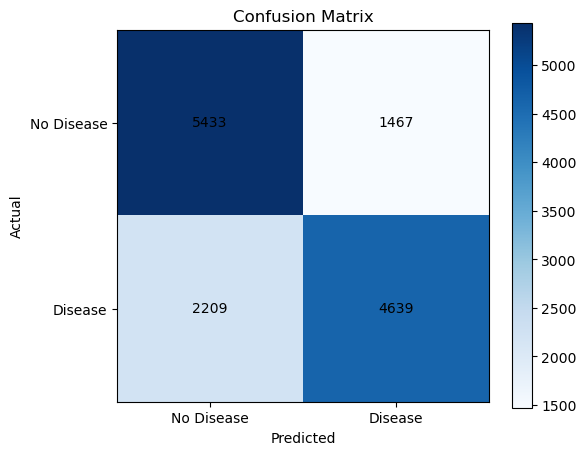

In [147]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')

plt.colorbar()

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.yticks([0,1], ['No Disease', 'Disease'])

# Add numbers inside matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='black')

plt.show()

In [149]:
sample=X_test[0].reshape(1,-1)

result=best_model.predict(sample)

if result[0]==1:
    print('Heart Disease Risk Present')
else:
    print('No Heart Disease Risk')

No Heart Disease Risk
